In [4]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load data*--
df = pd.read_csv(r'C:\Users\NITRO 5\Documents\Kuliah\Statprob\proyek1\proyek1-eda-kelompok-01\Attack_Dataset.csv')

In [6]:
# Cek 5 baris pertama
df.head()

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN


## Pemeriksaan Kualitas Data
Berikut ini adalah kumpulan kode-kode untuk memeriksa kualitas data pada dataset:

### 1. Pemeriksaan Tipe Data

In [10]:
#Tipe data setiap kolom
print("\nTipe data setiap kolom")
print(df.info())


Tipe data setiap kolom
<class 'pandas.DataFrame'>
RangeIndex: 14133 entries, 0 to 14132
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    14133 non-null  int64
 1   Title                 14133 non-null  str  
 2   Category              14133 non-null  str  
 3   Attack Type           14133 non-null  str  
 4   Scenario Description  14133 non-null  str  
 5   Tools Used            14119 non-null  str  
 6   Attack Steps          14133 non-null  str  
 7   Target Type           14129 non-null  str  
 8   Vulnerability         14115 non-null  str  
 9   MITRE Technique       14109 non-null  str  
 10  Impact                14130 non-null  str  
 11  Detection Method      14129 non-null  str  
 12  Solution              14130 non-null  str  
 13  Tags                  14130 non-null  str  
 14  Source                13973 non-null  str  
 15  Unnamed: 15           46 non-null     st

**Hasil pemeriksaan:**

Dataset terdiri dari 14.133 baris dan 16 kolom. Kolom `ID` memiliki tipe data `int64`, sedangkan sebagian besar kolom lainnya bertipe `str` karena berisi informasi berbentuk teks.

Ditemukan kolom `Unnamed: 15` yang hampir seluruh nilainya kosong, sehingga kolom tersebut tidak memberikan informasi yang berarti untuk analisis.

### 2. Pemeriksaan Baris dan Kolom

Pemeriksaan Baris dan Kolom dilakukan untuk mengetahui jumlahnya. Fungsi `df.shape()` digunakan untuk jumlah masing-masing baris dan kolom. 

In [13]:
# Berapa baris dan kolom?
print("\nBaris, Kolom:", df.shape)


Baris, Kolom: (14133, 16)


**Hasil Pemeriksaan:**

Diketahui bahwa terdapat 14.133 baris dan 16 kolom

### 3. Pemeriksaan Nama Kolom

Pemeriksaan ini dilakukan untuk mengetahui nama dari masing masing kolom dataset

In [11]:
# Nama kolom
print("\nKolom:")
print(df.columns.tolist())


Kolom:
['ID', 'Title', 'Category', 'Attack Type', 'Scenario Description', 'Tools Used', 'Attack Steps ', 'Target Type', 'Vulnerability', 'MITRE Technique', 'Impact', 'Detection Method', 'Solution', 'Tags', 'Source', 'Unnamed: 15']


Output diatas adalah nama-nama kolom yang dihasilkan dari fungsi `df.column.tolist()`.

### 4. Pemeriksaan Data Duplikat

Pemeriksaan duplikat dilakukan untuk mengetahui apakah terdapat baris yang memiliki data yang sama secara keseluruhan. Fungsi `df.duplicated()` digunakan untuk mendeteksi baris duplikat, kemudian `.sum()` digunakan untuk menghitung jumlahnya.

In [10]:
# Duplikat
print("\nJumlah duplikat:", df.duplicated().sum())


Jumlah duplikat: 0


Output kode menumjukkan bahwa pada dataset ini tidak ditemukan duplikat.

In [20]:
# Missing values per kolom
print("Missing values:")
print(df.isna().sum())

Missing values:
ID                      0
Title                   0
Category                0
Attack Type             0
Scenario Description    0
Tools Used              0
Attack Steps            0
Target Type             4
Vulnerability           0
MITRE Technique         0
Impact                  3
Detection Method        4
Solution                3
Tags                    3
Source                  0
dtype: int64


Kode berikut digunakan untuk mengetahui jumlah data yang kosong (missing values) pada setiap kolom dalam dataset. Fungsi `df.isna()` digunakan untuk mendeteksi data yang kosong, kemudian `.sum()` menghitung jumlah missing values pada masing-masing kolom.

Berdasarkan hasil pemeriksaan, masih terdapat missing values pada beberapa kolom, yaitu `Target Type` sebanyak 4 data, `Impact` sebanyak 3 data, `Detection Method` sebanyak 4 data, `Solution` sebanyak 3 data, dan `Tags` sebanyak 3 data. Kolom lainnya tidak memiliki missing values.

In [21]:
# Persentase missing
print("\nPersentase missing:")
print((df.isna().sum() / len(df)) * 100)


Persentase missing:
ID                      0.000000
Title                   0.000000
Category                0.000000
Attack Type             0.000000
Scenario Description    0.000000
Tools Used              0.000000
Attack Steps            0.000000
Target Type             0.028303
Vulnerability           0.000000
MITRE Technique         0.000000
Impact                  0.021227
Detection Method        0.028303
Solution                0.021227
Tags                    0.021227
Source                  0.000000
dtype: float64


Kode berikut digunakan untuk menghitung persentase data yang kosong pada setiap kolom. Jumlah missing values dibagi dengan jumlah seluruh baris (`len(df)`), kemudian dikalikan 100 untuk mendapatkan persentasenya.

Hasil menunjukkan bahwa missing values hanya terdapat pada beberapa kolom, yaitu `Target Type` sebesar 0,0283%, `Impact` sebesar 0,0212%, `Detection Method` sebesar 0,0283%, `Solution` sebesar 0,0212%, dan `Tags` sebesar 0,0212%. Persentase missing values tersebut sangat kecil dibandingkan dengan jumlah keseluruhan data.

### 5. Keputusan dan Pembersihan Data

Berdasarkan hasil pemeriksaan, kolom `Unnamed: 15` akan dihapus karena sebagian besar nilainya kosong dan tidak memberikan informasi yang relevan.

Missing values pada kolom yang berisi informasi penting tidak dihapus karena jumlahnya sangat kecil. Untuk mempertahankan seluruh baris dataset, missing values akan diganti dengan nilai `Unknown`.

Data duplikat tidak perlu ditangani karena tidak ditemukan baris duplikat.

In [15]:
# 1. Drop kolom kosong
df = df.drop(columns=['Unnamed: 15'])

In [16]:
# 2. isi missing dengan "Unknown"
df['Source'] = df['Source'].fillna('Unknown')
df['MITRE Technique'] = df['MITRE Technique'].fillna('Unknown')
df['Vulnerability'] = df['Vulnerability'].fillna('Unknown')
df['Tools Used'] = df['Tools Used'].fillna('Unknown')

### 6. Pemeriksaan Ulang Setelah Pembersihan

Setelah proses pembersihan dilakukan, dataset diperiksa kembali untuk memastikan bahwa kolom yang tidak diperlukan telah dihapus dan tidak terdapat lagi missing values.

In [24]:
print("Missing values setelah cleaning:")
print(df.isna().sum())

print("\nUkuran dataset setelah cleaning:")
print(df.shape)

Missing values setelah cleaning:
ID                      0
Title                   0
Category                0
Attack Type             0
Scenario Description    0
Tools Used              0
Attack Steps            0
Target Type             4
Vulnerability           0
MITRE Technique         0
Impact                  3
Detection Method        4
Solution                3
Tags                    3
Source                  0
dtype: int64

Ukuran dataset setelah cleaning:
(14133, 15)


In [18]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique")

ID: 14133 unique
Title: 13793 unique
Category: 64 unique
Attack Type: 8834 unique
Scenario Description: 13866 unique
Tools Used: 12936 unique
Attack Steps : 13895 unique
Target Type: 9885 unique
Vulnerability: 13425 unique
MITRE Technique: 5771 unique
Impact: 13187 unique
Detection Method: 13813 unique
Solution: 13852 unique
Tags: 13817 unique
Source: 7052 unique


In [19]:
# 1. Cek Category (64 unique, masih mungkin dibaca)
print("=== CATEGORY ===")
print(df['Category'].value_counts())

=== CATEGORY ===
Category
Insider Threat                                           569
Physical / Hardware Attacks                              548
Quantum Cryptography & Post-Quantum Threats              542
Wireless Attacks (Advanced)                              535
Malware & Threat                                         528
                                                        ... 
Automotive / CPS → Sensor Spoofing                         7
Automotive / CPS → Firmware Over-The-Air (FOTA) Abuse      5
Automotive / CPS → Physical Layer Attack                   3
Network security                                           2
 Mobile Security                                           1
Name: count, Length: 64, dtype: int64


In [20]:
# 2. Cek Target Type (9.885 unique, lihat 20 teratas)
print("\n=== TARGET TYPE (Top 20) ===")
print(df['Target Type'].value_counts().head(20))


=== TARGET TYPE (Top 20) ===
Target Type
Windows                     291
Workstation                 109
Satellite                    78
Endpoint                     50
Android App                  46
Windows Host                 42
Wireless Networks            36
GitHub Actions               36
Infotainment System          35
Windows Workstation          34
PLC                          33
Internal Network             31
Passenger Vehicle            31
ECU                          30
Android Device               28
Ethereum Smart Contracts     28
Wallet Users                 28
Windows Hosts                26
Workstations                 26
Kubernetes Cluster           25
Name: count, dtype: int64


In [21]:
# 3. Cek Tags (formatnya apa?)
print("\n=== TAGS (5 contoh) ===")
print(df['Tags'].dropna().head(5).tolist())


=== TAGS (5 contoh) ===
['SQLi, Authentication Bypass, Web Security, OWASP Top 10', '#SQLInjection #WebSecurity #UnionAttack #OWASPTop10 #InjectionFlaws', '#SQLInjection #ErrorLeakage #WebAppSecurity #OWASPTop10 #DatabaseSecurity', '#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWASPTop10 #DatabaseHacking', '#SecondOrderSQLi #DelayedInjection #StoredInjection #WebSecurity #OWASPTop10']


In [22]:
# 4. Cek Tools Used (formatnya apa?)
print("\n=== TOOLS USED (5 contoh) ===")
print(df['Tools Used'].dropna().head(5).tolist())


=== TOOLS USED (5 contoh) ===
['Browser, Burp Suite, SQLMap', 'SQLMap, Burp Suite, Havij, Browser Developer Tools', 'SQLMap, Burp Suite, Manual Browser Testing, Havij', 'SQLMap, Burp Suite, sqlninja, Manual Browser Testing, Python Scripts', 'Burp Suite, SQLMap, Postman, Browser Dev Tools, Manual Testing']


In [23]:
# 5. Cek MITRE Technique (formatnya apa?)
print("\n=== MITRE (5 contoh) ===")
print(df['MITRE Technique'].dropna().head(5).tolist())


=== MITRE (5 contoh) ===
['T1078 (Valid Accounts), T1190 (Exploit Public-Facing App)', 'T1190 – Exploit Public-Facing Application', 'T1190 – Exploit Public-Facing Application', 'T1190 – Exploit Public-Facing Application', 'T1505.003 – SQL Injection']


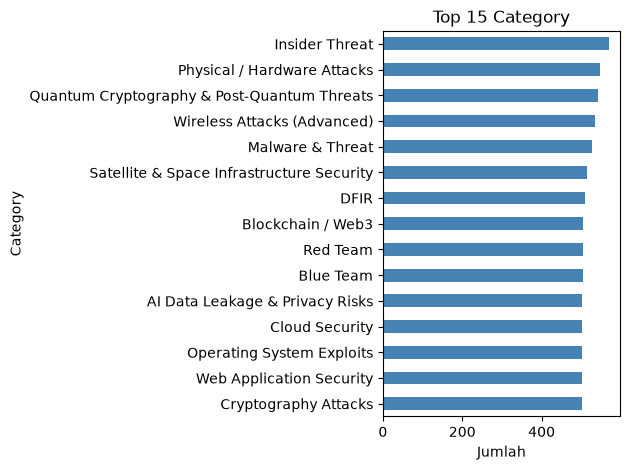

In [24]:
df['Category'].value_counts().head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Category')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# Split, explode, strip
tools = df['Tools Used'].dropna().str.split(',').explode().str.strip()

# Hitung frekuensi
tools_count = tools.value_counts()
print("Total unique tools:", tools_count.shape[0])
print("\nTop 15 Tools:")
print(tools_count.head(15))

Total unique tools: 14906

Top 15 Tools:
Tools Used
Burp Suite        1117
Wireshark          711
Python             507
curl               486
Postman            289
PowerShell         265
bash               251
Scapy              234
Browser            196
PyTorch            190
Ghidra             184
AFL++              182
GitHub             180
Hardhat            177
Android Studio     166
Name: count, dtype: int64


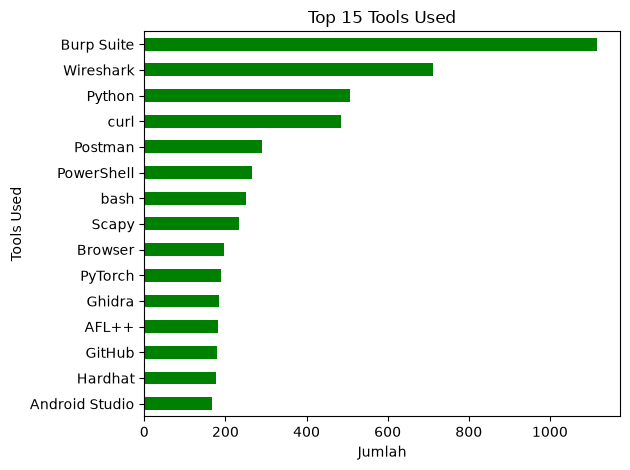

In [26]:
tools_count.head(15).plot(kind='barh', color='green')
plt.title('Top 15 Tools Used')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
import re

def extract_mitre(x):
    return re.findall(r'T\d{4}(?:\.\d{3})?', str(x))

mitre = df['MITRE Technique'].dropna().apply(extract_mitre).explode()
mitre_count = mitre.value_counts()

print("Total unique MITRE technique:", mitre_count.shape[0])
print(mitre_count.head(15))

Total unique MITRE technique: 772
MITRE Technique
T1203        740
T1499        401
T1606        352
T1552.001    302
T1040        280
T1557        280
T1609        271
T1600        259
T1059        239
T1204.002    235
T1059.007    219
T1078        213
T1557.002    202
T1190        196
T1530        188
Name: count, dtype: int64


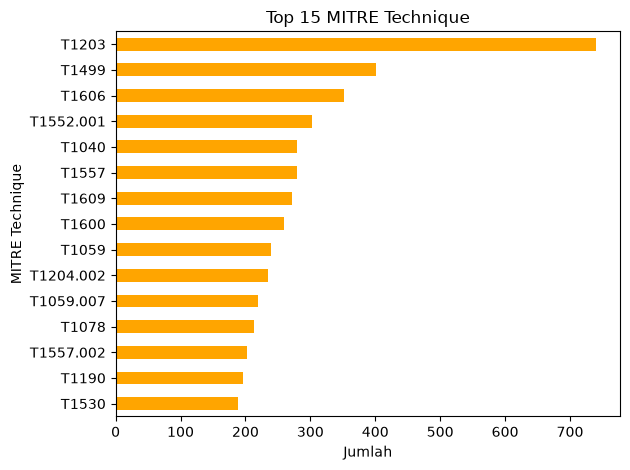

In [31]:
mitre_count.head(15).plot(kind='barh', color='orange')
plt.title('Top 15 MITRE Technique')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
# Mapping manual untuk teknik yang sering muncul
mitre_names = {
    'T1190': 'Exploit Public-Facing App',
    'T1078': 'Valid Accounts',
    'T1059': 'Command & Scripting Interpreter',
    'T1059.007': 'JavaScript Execution',
    'T1110': 'Brute Force',
    'T1110.001': 'Password Guessing',
    'T1110.004': 'Credential Stuffing',
    'T1505.003': 'Web Shell / SQL Injection',
    'T1530': 'Data from Local System',
    'T1552': 'Unsecured Credentials',
    'T1552.001': 'Credentials in Files',
    'T1555.003': 'Credentials from Password Stores',
    'T1040': 'Network Sniffing',
    'T1048': 'Exfiltration Over Alt Protocol',
    'T1075': 'Pass the Session',
    'T1189': 'Drive-by Compromise',
    'T1203': 'Exploitation for Client Exec',
    'T1556.004': 'MFA Bypass',
    'T1589': 'Gather Victim Identity Info',
    'T1606.001': 'Forge Web Credentials',
}

# Tambahkan nama ke tabel
mitre_df = mitre_count.head(15).reset_index()
mitre_df.columns = ['MITRE Code', 'Count']
mitre_df['Technique Name'] = mitre_df['MITRE Code'].map(mitre_names).fillna('Unknown')
print(mitre_df)

   MITRE Code  Count                   Technique Name
0       T1203    740     Exploitation for Client Exec
1       T1499    401                          Unknown
2       T1606    352                          Unknown
3   T1552.001    302             Credentials in Files
4       T1040    280                 Network Sniffing
5       T1557    280                          Unknown
6       T1609    271                          Unknown
7       T1600    259                          Unknown
8       T1059    239  Command & Scripting Interpreter
9   T1204.002    235                          Unknown
10  T1059.007    219             JavaScript Execution
11      T1078    213                   Valid Accounts
12  T1557.002    202                          Unknown
13      T1190    196        Exploit Public-Facing App
14      T1530    188           Data from Local System


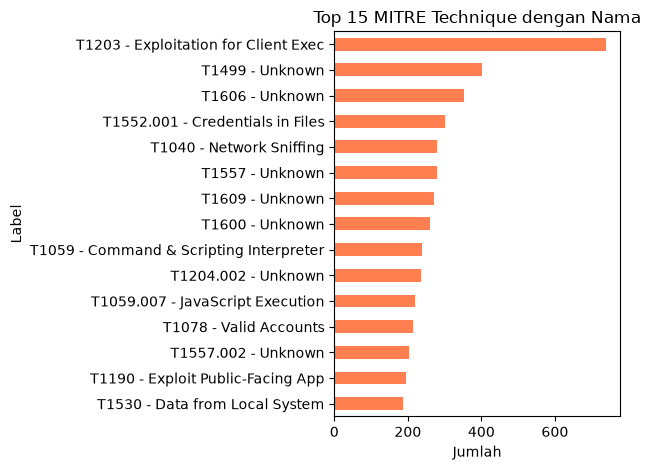

In [33]:
# Gabung kode + nama untuk label
mitre_df['Label'] = mitre_df['MITRE Code'] + ' - ' + mitre_df['Technique Name']

mitre_df.set_index('Label')['Count'].plot(kind='barh', color='coral')
plt.title('Top 15 MITRE Technique dengan Nama')
plt.xlabel('Jumlah')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()